In [2]:
import tensorflow as tf
print(tf.__version__)


2.15.0


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np


In [10]:
print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.15.0


In [12]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


170498071/170498071 [==============================] - 69s 0us/step
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


In [14]:
X_train = X_train / 255.0
X_test = X_test / 255.0


In [16]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [18]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))


In [22]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [24]:
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 2304)              0         
                                                                 
 dense (Dense)               (None, 128)               2

In [26]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/10


625/625 [==============================] - 34s 48ms/step - loss: 1.6972 - accuracy: 0.3817 - val_loss: 1.3785 - val_accuracy: 0.5214
Epoch 2/10
625/625 [==============================] - 26s 41ms/step - loss: 1.3737 - accuracy: 0.5081 - val_loss: 1.1798 - val_accuracy: 0.5920
Epoch 3/10
625/625 [==============================] - 26s 41ms/step - loss: 1.2301 - accuracy: 0.5660 - val_loss: 1.0970 - val_accuracy: 0.6199
Epoch 4/10
625/625 [==============================] - 26s 41ms/step - loss: 1.1559 - accuracy: 0.5924 - val_loss: 1.0449 - val_accuracy: 0.6367
Epoch 5/10
625/625 [==============================] - 26s 42ms/step - loss: 1.0879 - accuracy: 0.6177 - val_loss: 0.9889 - val_accuracy: 0.6558
Epoch 6/10
625/625 [==============================] - 26s 42ms/step - loss: 1.0353 - accuracy: 0.6373 - val_loss: 0.9984 - val_accuracy: 0.6510
Epoch 7/10
625/625 [==============================] - 26s 42ms/step - loss: 0.9889 - accuracy: 0.6549 - val_loss: 0.9151 - val_accurac

In [29]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)


313/313 [==============================] - 3s 11ms/step - loss: 0.9287 - accuracy: 0.6835
Test Accuracy: 0.6834999918937683


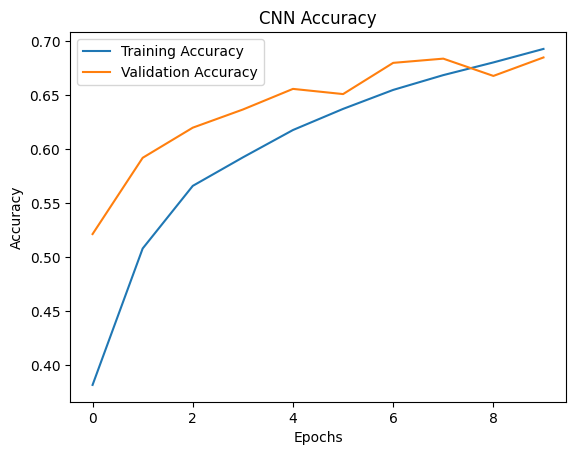

In [31]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.show()


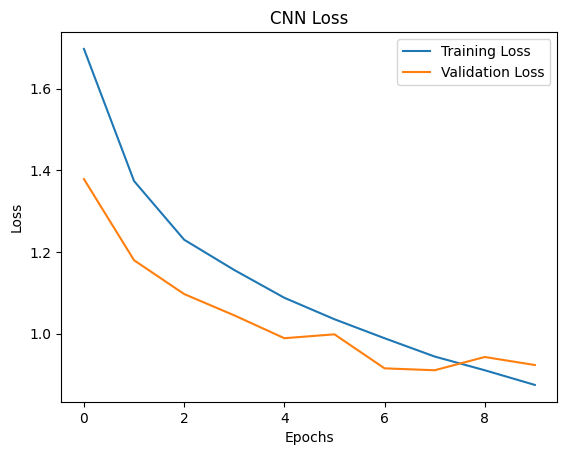

In [33]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()
plt.show()


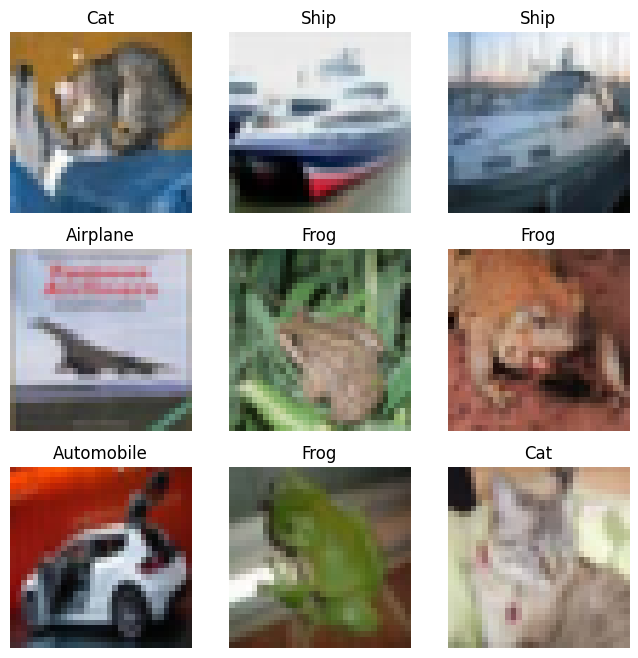

In [41]:
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i] , interpolation='nearest')
    plt.title(class_names[np.argmax(y_test[i])])
    plt.axis('off')
plt.show()


## Analysis
The CNN model learned visual features from CIFAR-10 images effectively.
Training and validation accuracy improved steadily, showing good learning behavior.
Dropout helped reduce overfitting.


## Conclusion
This project demonstrates image classification using a Convolutional Neural Network.
The CNN successfully classified images from the CIFAR-10 dataset, improving understanding
of deep learning and CNN architecture.
